# Access 4DMED-SEA 4DVarNet 1/20°

[Explore Data](https://sunnydean.github.io/ocean_cubes_vis/?cube=https%3A%2F%2Fs3.waw4-1.cloudferro.com%2FEarthCODE%2FOSCAssets%2Fmed_cubes%2Focean-med-daily-surface-cube.zarr&variable=sla_4dvarnet_ssh)

    * Original Data Source: zenodo.org/records/10912777
    * Reference:  https://doi.org/10.3390/rs14102502
    * OSC entry: https://opensciencedata.esa.int/stac-browser/#/products/4dmed-2d-alt-varnet-20/collection.json
    * License: CC-BY-4.0

In [1]:
import xarray as xr

zarr_href = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/ocean_datasets/4dvarnet-ssh.zarr/'

In [2]:
ds = xr.open_zarr(zarr_href)
ds

<xarray.Dataset> Size: 52GB
Dimensions:             (time: 2405, latitude: 378, longitude: 1012)
Coordinates:
  * time                (time) datetime64[ns] 19kB 2016-01-01 ... 2022-08-01
  * latitude            (latitude) float32 2kB 30.27 30.31 30.35 ... 45.94 45.98
  * longitude           (longitude) float32 4kB -6.062 -6.021 ... 36.02 36.06
Data variables:
    adt                 (time, latitude, longitude) float64 7GB dask.array<chunksize=(30, 378, 1012), meta=np.ndarray>
    relative_vorticity  (time, latitude, longitude) float64 7GB dask.array<chunksize=(30, 378, 1012), meta=np.ndarray>
    sla                 (time, latitude, longitude) float64 7GB dask.array<chunksize=(30, 378, 1012), meta=np.ndarray>
    ugos                (time, latitude, longitude) float64 7GB dask.array<chunksize=(30, 378, 1012), meta=np.ndarray>
    ugosa               (time, latitude, longitude) float64 7GB dask.array<chunksize=(30, 378, 1012), meta=np.ndarray>
    vgos                (time, latitude, longitude) float64 7GB dask.array<chunksize=(30, 378, 1012), meta=np.ndarray>
    vgosa               (time, latitude, longitude) float64 7GB dask.array<chunksize=(30, 378, 1012), meta=np.ndarray>

In [3]:
snapshot = ds.sel(time="2016-05-22")
snapshot

<xarray.Dataset> Size: 21MB
Dimensions:             (latitude: 378, longitude: 1012)
Coordinates:
  * latitude            (latitude) float32 2kB 30.27 30.31 30.35 ... 45.94 45.98
  * longitude           (longitude) float32 4kB -6.062 -6.021 ... 36.02 36.06
    time                datetime64[ns] 8B 2016-05-22
Data variables:
    adt                 (latitude, longitude) float64 3MB dask.array<chunksize=(378, 1012), meta=np.ndarray>
    relative_vorticity  (latitude, longitude) float64 3MB dask.array<chunksize=(378, 1012), meta=np.ndarray>
    sla                 (latitude, longitude) float64 3MB dask.array<chunksize=(378, 1012), meta=np.ndarray>
    ugos                (latitude, longitude) float64 3MB dask.array<chunksize=(378, 1012), meta=np.ndarray>
    ugosa               (latitude, longitude) float64 3MB dask.array<chunksize=(378, 1012), meta=np.ndarray>
    vgos                (latitude, longitude) float64 3MB dask.array<chunksize=(378, 1012), meta=np.ndarray>
    vgosa               (latitude, longitude) float64 3MB dask.array<chunksize=(378, 1012), meta=np.ndarray>

In [4]:
import numpy as np

sla_limit = float(np.nanpercentile(np.abs(snapshot.sla), 98))

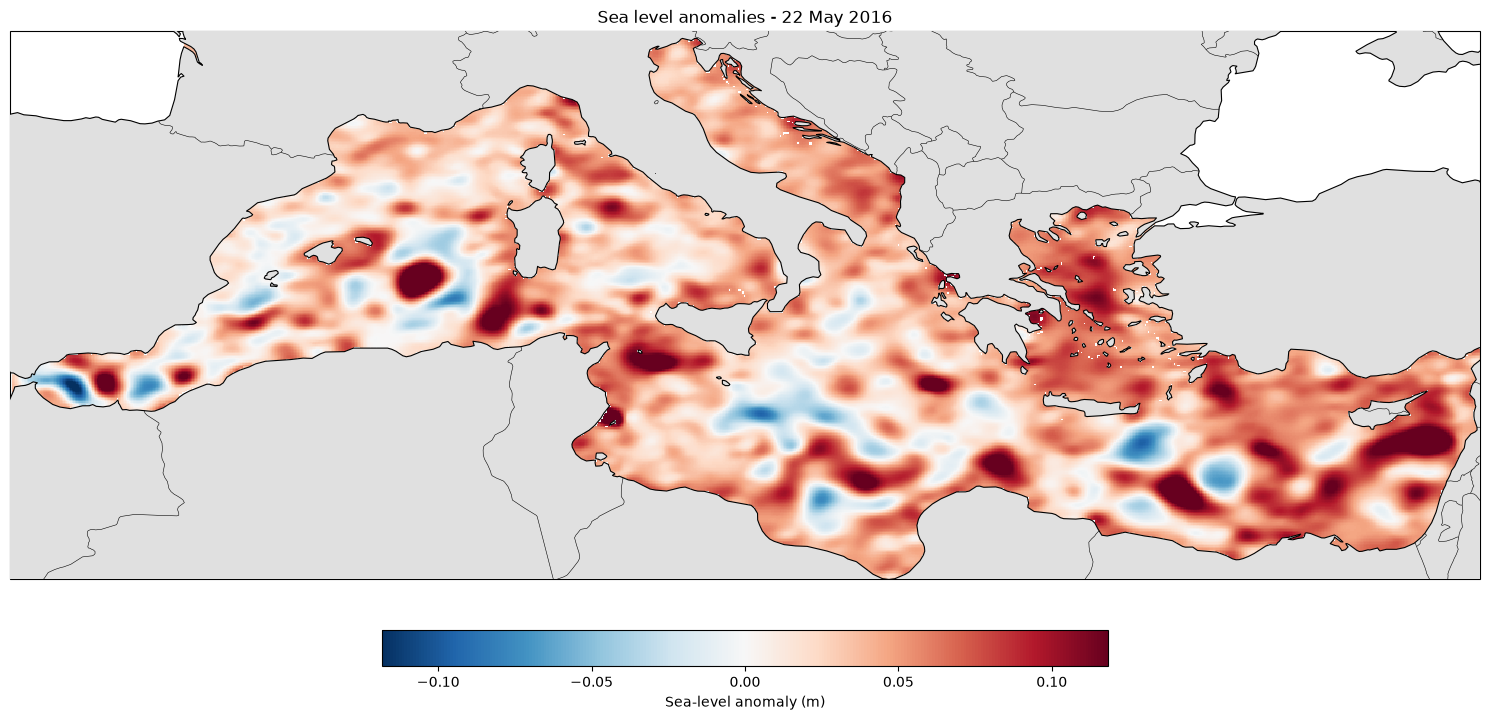

In [5]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(15, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([
    float(snapshot.longitude.min()),
    float(snapshot.longitude.max()),
    float(snapshot.latitude.min()),
    float(snapshot.latitude.max())
], crs=ccrs.PlateCarree())

# Plot SLA with limits centred on zero so positive and negative anomalies are comparable
sla_plot = ax.pcolormesh(
    snapshot.longitude,
    snapshot.latitude,
    snapshot.sla,
    cmap="RdBu_r",
    vmin=-sla_limit,
    vmax=sla_limit,
    shading="auto",
    transform=ccrs.PlateCarree()
)

# Add coastlines and land to provide geographic context
ax.add_feature(cfeature.LAND, facecolor="0.88", zorder=3)
ax.coastlines(resolution="50m", linewidth=0.8, zorder=4)
ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=4)


# Explain the SLA colours and vorticity contour meanings
colorbar = plt.colorbar(
    sla_plot,
    ax=ax,
    orientation="horizontal",
    pad=0.07,
    fraction=0.05
)
colorbar.set_label("Sea-level anomaly (m)")


ax.set_title(
    "Sea level anomalies - 22 May 2016"
)

plt.tight_layout()
plt.show()